In [1]:
import numpy as np
import scipy
import scipy.linalg as sla
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['figure.dpi'] = 140

In [2]:
def univariate_spectral(A, B, k, xs):
    """Computes the vector y[i] = λₖ(A + B * xs[i])."""
    
    # support negative eigenvalue indices,
    #  e.g., k=-1 is the largest eigenvalue
    k = k % A.shape[0]
    
    # create a batch of matrices, one for each entry in xs
    mats = A + B * xs[..., np.newaxis, np.newaxis]
    
    # compute the k-th eigenvalue of each matrix
    return sla.eigvalsh(mats, subset_by_index=(k, k)).squeeze()

In [3]:
def spec_neuron_gallery(A, B, n_rows, n_cols):
    """Plots λₖ(A + B * x) on a grid layout"""
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2 * n_rows), layout='constrained')
    plot_xs = np.linspace(-3, 3, 1000)
    for k, ax in enumerate(axs.ravel()):
        if k >= A.shape[-1]:
            break
        ax.plot(plot_xs, univariate_spectral(A, B, k, plot_xs))
        ax.set_title(f'$\\lambda_{{{1 + k}}}(A + B * x)$')
    plt.show()  

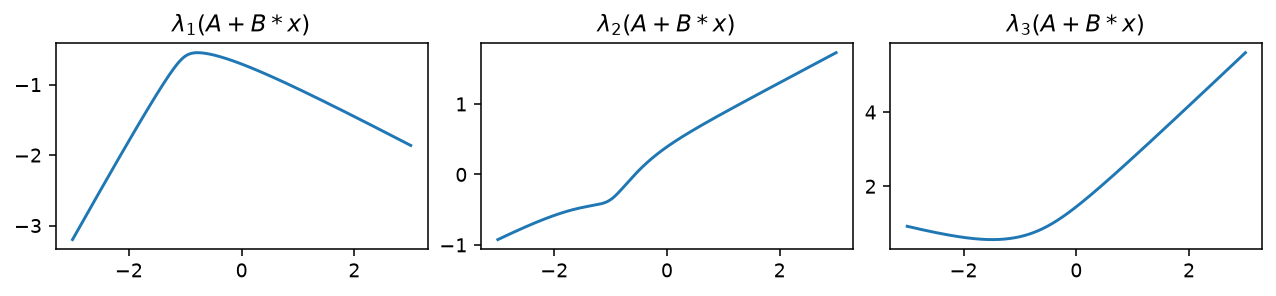

In [4]:
np.random.seed(42)
A = np.random.rand(3, 3)
B = np.random.rand(3, 3)
spec_neuron_gallery(A, B, 1, 3)

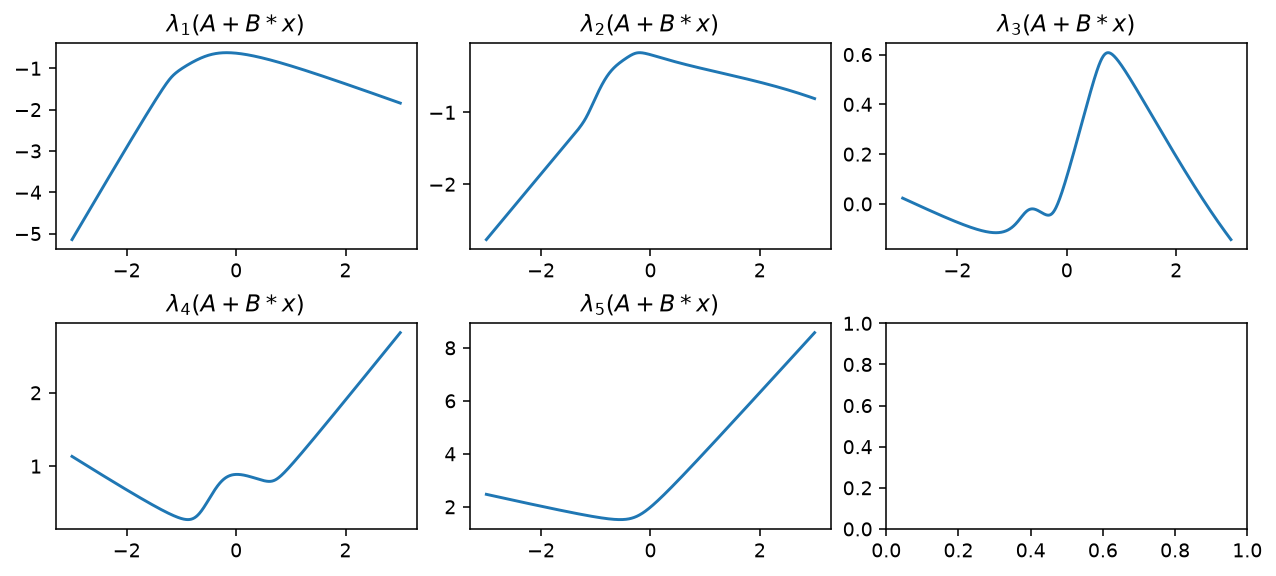

In [5]:
np.random.seed(42)
A = np.random.rand(5, 5)
B = np.random.rand(5, 5)
spec_neuron_gallery(A, B, 2, 3)

In [6]:
def spec_neuron_multiplot(A, B):
    """Plots λₖ(A + B * x) on one axis"""
    fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
    plot_xs = np.linspace(-3, 3, 1000)

    color_indices = np.linspace(0, 1, 2 + A.shape[-1])[1:-1]
    colors = mpl.colormaps['berlin'](color_indices)
    widths = np.linspace(1.5, 2.5, A.shape[-1])
    
    for k in range(A.shape[-1]):
        ax.plot(plot_xs, univariate_spectral(A, B, k, plot_xs),
                label=f'$\\lambda_{{{1 + k}}}(A + B * x)$',
                linewidth=widths[k],
                c=colors[k])
    ax.grid()
    ax.legend()

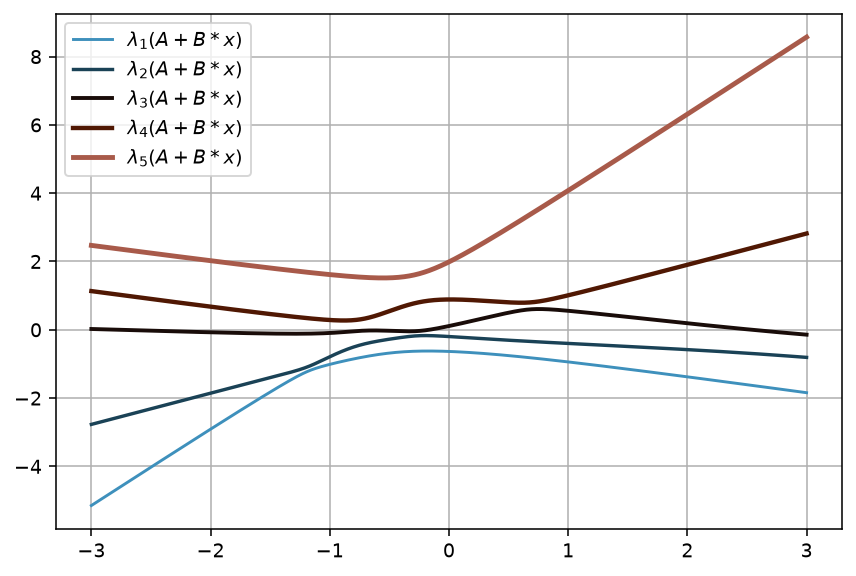

In [7]:
spec_neuron_multiplot(A, B)

In [8]:
def make_psd(B):
    eigvals, eigvecs = sla.eigh(B)
    eigvals_pos = np.maximum(0, eigvals)
    return eigvecs @ np.diag(eigvals_pos) @ eigvecs.T

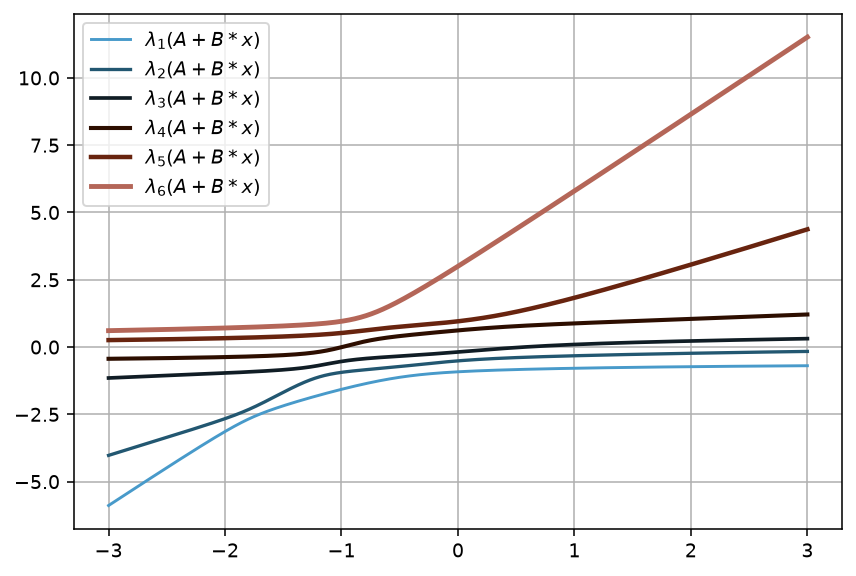

In [9]:
np.random.seed(42)
A = np.random.rand(6, 6)
B = np.random.rand(6, 6)
spec_neuron_multiplot(A, make_psd(B))

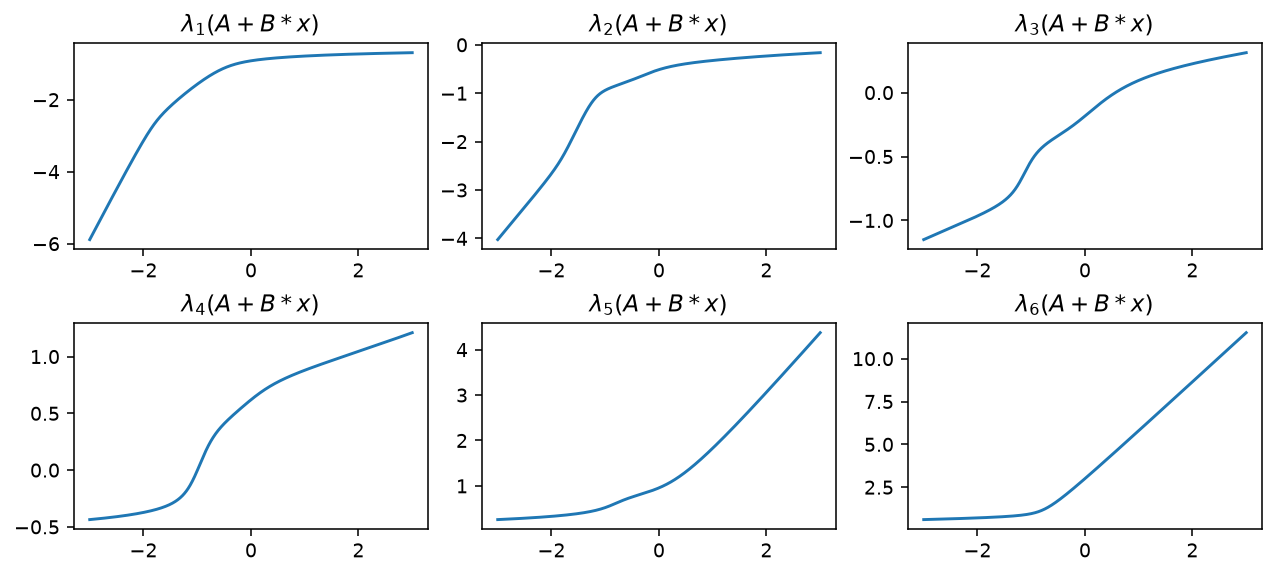

In [10]:
spec_neuron_gallery(A, make_psd(B), 2, 3)